# FDDES Project 2026

This is the main working file of the project. Here, we review the computations done in "fdd/...". This acts as the main pipeline (imports and runs preprocessing, fd-methods, evaluation, etc).   

## Faulty cases - Ground truth
We know the start and end times of the faults in the different cases which serves as a ground truth to compare the results with.

In [1]:
SEfc1_1 = [1566, 5181] # Fault start and end for FaultyCase1 set 1.1
SEfc1_2 = [657, 3777]
SEfc1_3 = [691, 3691]

SEfc2_1 = [2244, 6616]
SEfc2_2 = [476, 2656]
SEfc2_3 = [331, 2467]

SEfc3_1 = [1136, 8352]
SEfc3_2 = [333, 5871]
SEfc3_3 = [596, 9566]

SEfc4_1 = [953, 6294]
SEfc4_2 = [851, 3851]
SEfc4_3 = [241, 3241]

SEfc5_1 = [686, 1172, 1772, 2253] # Fault start and end for FaultyCase5 set 5.1 with two faults
SEfc5_2 = [1633, 2955, 7031, 7553, 8057, 10608] # with three faults

SEfc6_1 = [1723, 2800]
SEfc6_2 = [1037, 4830]

# cases, sets, and their corresponding fault windows
se_windows = {
    "FaultyCase1": {"Set1_1": SEfc1_1, "Set1_2": SEfc1_2, "Set1_3": SEfc1_3},
    "FaultyCase2": {"Set2_1": SEfc2_1, "Set2_2": SEfc2_2, "Set2_3": SEfc2_3},
    "FaultyCase3": {"Set3_1": SEfc3_1, "Set3_2": SEfc3_2, "Set3_3": SEfc3_3},
    "FaultyCase4": {"Set4_1": SEfc4_1, "Set4_2": SEfc4_2, "Set4_3": SEfc4_3},
    "FaultyCase5": {"Set5_1": SEfc5_1, "Set5_2": SEfc5_2},
    "FaultyCase6": {"Set6_1": SEfc6_1, "Set6_2": SEfc6_2}
}

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Data loading

In [ ]:
from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor

loader = DataLoader()

# Training data 
trainsets = loader.load("Training")

# Faulty cases (test data)
FC1sets = loader.load("FaultyCase1")
FC2sets = loader.load("FaultyCase2")
FC3sets = loader.load("FaultyCase3")
FC4sets = loader.load("FaultyCase4")
FC5sets = loader.load("FaultyCase5")
FC6sets = loader.load("FaultyCase6")

# Keep raw fault sets unchanged. The preprocessed version is created later.
raw_fc_sets = [FC1sets, FC2sets, FC3sets, FC4sets, FC5sets, FC6sets]
fc_sets = raw_fc_sets

# Training

## Preprocessing

In [4]:
# Centering and scaling

train_set_1 = trainsets["T1"] # others are "T2" and "T3"
print(train_set_1.summary())

preprocessor = StandardPreprocessor(with_standardization=True, remove_outliers=True)
X_processed = preprocessor.fit_transform(train_set_1)

X = X_processed.sensors

X_processed.sensors.head()

TimeSeriesDataset(name=T1, n_samples=10372, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,-1.307753,-1.220328,-1.052915,-0.796591,-1.371278,-1.001754,-0.363136,-1.064570,-0.992732,-0.515347,...,0.272372,1.100414,1.723288,2.430264,0.233425,2.364709,-1.256794,-1.132945,-1.044812,-1.230878
1,-1.302288,-1.214186,-1.031293,-0.770547,-1.316702,-0.992804,-0.312178,-1.031065,-0.992719,-0.515351,...,0.271160,1.099402,1.706738,2.421200,0.399604,2.356275,-1.260444,-1.141621,-1.044834,-1.483801
2,-1.296337,-1.216351,-0.953502,-0.744440,-1.262087,-0.993475,-0.082862,-1.018832,-0.992707,-0.515355,...,0.269947,1.098138,1.690189,2.412140,0.399604,2.347845,-1.264090,-1.150296,-1.044856,-0.851493
3,-1.290375,-1.209101,-0.983748,-0.718405,-1.207490,-0.994145,-0.575466,-1.019288,-0.992694,-0.515360,...,0.268734,1.097126,1.673640,2.403081,0.399604,2.339403,-1.267737,-1.155395,-1.044879,-1.315186
4,-1.284424,-1.194787,-0.979399,-0.732329,-1.152894,-0.988634,-0.643412,-1.035173,-0.992681,-0.515364,...,0.267522,1.095862,1.657086,2.394021,0.406259,2.330969,-1.271387,-1.156916,-1.044901,-2.284724


## Shewhart

In [5]:
mean = X.mean()
std = X.std()
shewhart_threshold = mean + 3 * std # Shewhart control limit (3-sigma rule)

## PCA

Original X shape: (5672, 23)
PCA-transformed Z shape: (5672, 2)
Explained variance ratio: [0.50947728 0.14943127]
Cumulative explained variance: [0.50947728 0.65890855]
Total explained variance: 0.6589085498607736
         Z1        Z2
0 -1.563914  3.770866
1 -1.615547  3.770845
2 -1.522761  3.683866
3 -1.672788  3.733511
4 -1.642192  3.767074


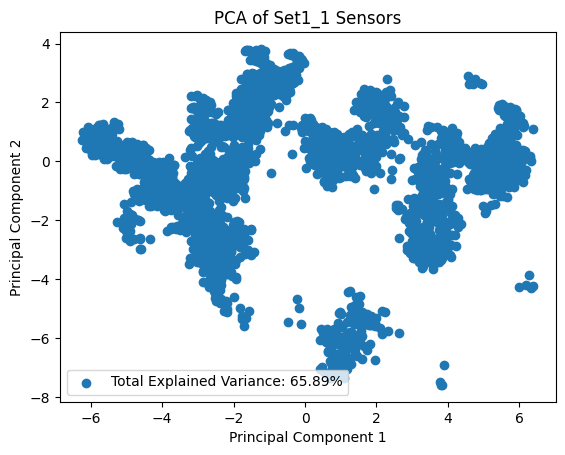

In [6]:
from fdd.pca import pca_fit
from fdd.pca import pca_transform

pca_model = pca_fit(X, n_components=2)
Z_pca = pca_transform(X, pca_model)
evr_pca = pca_model["explained_variance_ratio"]

print('Original X shape:', X.shape)
print('PCA-transformed Z shape:', Z_pca.shape)
print('Explained variance ratio:', evr_pca.values)
print('Cumulative explained variance:', evr_pca.cumsum().values)
print('Total explained variance:', evr_pca.sum())
print(Z_pca.head())

plt.scatter(Z_pca["Z1"], Z_pca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Set1_1 Sensors")
plt.legend([f'Total Explained Variance: {evr_pca.sum()*100:.2f}%'])          
plt.show()

The total explained variance is only 47% meaning only 47% of the data can be explained with these two principal components. Therefore a 2D PCA is mainly used for visualization and not as a complete representation. 

Since X has been reduced down to 2 "features" in Z, that makes us able to plot them.

### Q and T2 statistics for PCA

In [ ]:
from fdd.statistics import q_statistic, t2_statistic

# Compute PCA monitoring statistics on healthy training data.
# Classical PCA reconstruction is used inside q_statistic:
#   X_hat = T P^T
#   Q = sum((X - X_hat)^2)
# Classical PCA T² is used inside t2_statistic:
#   T² = sum(t_i^2 / lambda_i)

q_train_pca = q_statistic(X, Z_pca, pca_model)
t2_train_pca = t2_statistic(Z_pca, pca_model)

# Thresholds are estimated empirically from healthy training data.
threshold_q_pca = np.percentile(q_train_pca, 95)
threshold_t2_pca = np.percentile(t2_train_pca, 95)

print("PCA Q threshold:", threshold_q_pca)
print("PCA T² threshold:", threshold_t2_pca)

In [ ]:
# Plot PCA Q-statistic and T² statistic over time with thresholds

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(q_train_pca, label="Q statistic / SPE")
plt.axhline(
    y=threshold_q_pca,
    color="r",
    linestyle="--",
    label=f"95% Threshold: {threshold_q_pca:.2f}",
)
plt.xlabel("Sample")
plt.ylabel("Q statistic / SPE")
plt.title("PCA Q-statistic over time")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t2_train_pca, label="T² statistic")
plt.axhline(
    y=threshold_t2_pca,
    color="r",
    linestyle="--",
    label=f"95% Threshold: {threshold_t2_pca:.2f}",
)
plt.xlabel("Sample")
plt.ylabel("T² statistic")
plt.title("PCA T² statistic over time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

When finding the thresholds during training, a 95% threshold means that you can expect about 5% false alarms. 

## DPCA transform

Original X shape: (5672, 23)
DPCA-transformed Z shape: (5667, 2)
Explained variance ratio: [0.50714286 0.14763313]
Cumulative explained variance: [0.50714286 0.654776  ]
Total explained variance: 0.6547759985828696
         Z1        Z2
5 -3.801657 -9.145641
6 -3.695383 -9.101006
7 -3.601029 -9.101214
8 -3.485673 -9.154442
9 -3.262797 -9.167120


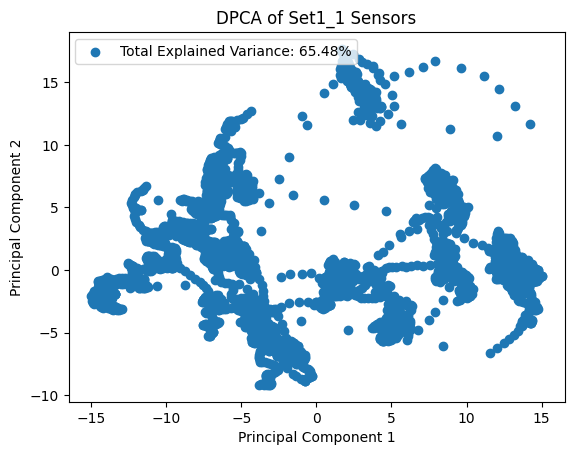

In [8]:
from fdd.dpca import dpca_fit
from fdd.dpca import dpca_transform
from fdd.dpca import dpca_prepare_matrix

dpca_model = dpca_fit(X, n_components=2, time_lags=5)
evr_dpca = dpca_model["explained_variance_ratio"]
Z_dpca = dpca_transform(X, dpca_model)

print('Original X shape:', X.shape)
print('DPCA-transformed Z shape:', Z_dpca.shape)
print('Explained variance ratio:', evr_dpca.values)
print('Cumulative explained variance:', evr_dpca.cumsum().values)
print('Total explained variance:', evr_dpca.sum())
print(Z_dpca.head())

plt.scatter(Z_dpca["Z1"], Z_dpca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DPCA of Set1_1 Sensors")
plt.legend([f'Total Explained Variance: {evr_dpca.sum()*100:.2f}%'])          
plt.show()

### Q and T2 statistic for DPCA

In [ ]:
from fdd.statistics import q_statistic, t2_statistic
from fdd.dpca import dpca_prepare_matrix

# Prepare the standardized lagged training matrix used by the DPCA model.
# Q-statistic must be computed in the same lagged/scaled input space.
X_lagged = dpca_prepare_matrix(X, dpca_model)

# Compute DPCA monitoring statistics on healthy training data.
q_values_dpca = q_statistic(
    X_lagged,
    Z_dpca,
    dpca_model["pca_model"],
)

t2_values_dpca = t2_statistic(
    Z_dpca,
    dpca_model["pca_model"],
)

# Thresholds are estimated empirically from healthy training data.
threshold_q_dpca = np.percentile(q_values_dpca, 95)
threshold_t2_dpca = np.percentile(t2_values_dpca, 95)

print("DPCA Q threshold:", threshold_q_dpca)
print("DPCA T² threshold:", threshold_t2_dpca)

In [ ]:
# Plot DPCA Q-statistic and T² statistic over time with thresholds

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(q_values_dpca, label="Q statistic / SPE")
plt.axhline(
    y=threshold_q_dpca,
    color="r",
    linestyle="--",
    label=f"95% Threshold: {threshold_q_dpca:.2f}",
)
plt.xlabel("Lagged sample")
plt.ylabel("Q statistic / SPE")
plt.title("DPCA Q-statistic over time")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t2_values_dpca, label="T² statistic")
plt.axhline(
    y=threshold_t2_dpca,
    color="r",
    linestyle="--",
    label=f"95% Threshold: {threshold_t2_dpca:.2f}",
)
plt.xlabel("Lagged sample")
plt.ylabel("T² statistic")
plt.title("DPCA T² statistic over time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Testing - Faulty cases

## Preprocessing of FC data

In [ ]:
# Preprocess fault/test datasets using the SAME preprocessor fitted on training data.
# Do not fit a new preprocessor on each fault case, because PCA/DPCA/FDA must use
# the same scaling reference as the healthy training data.

fc_sets = [
    {
        set_name: preprocessor.transform(dataset)
        for set_name, dataset in case_sets.items()
    }
    for case_sets in raw_fc_sets
]

X_test_processed = fc_sets[0]["Set1_1"]
X_test_processed.sensors.head()

## Shewhart testing

In [11]:
Shew_X_FC1_1 = fc_sets[0]["Set1_1"].sensors
shew_anomalies_fc1_1 = (Shew_X_FC1_1 > shewhart_threshold).sum()
print(shew_anomalies_fc1_1)
print(f"Total number of anomalies detected by Shewhart in FC1 Set 1.1: {shew_anomalies_fc1_1.sum()}")

Air_Delivery_P           2
P_Bottom_Riser         182
P_Top_Riser             70
P_Top_Separator         62
P_3Phase_Separator      82
Diff_P_Riser           193
Diff_P_VC404            62
Air_In_Flow              1
Water_In_Flow            0
Flow_Top_Riser          82
Level_Top_Sep            0
Flow_Top_Sep_Out        57
Density_Top_Riser      125
Density_Top_Sep_Out      0
Density_Water_In         0
Temp_Top_Riser           6
Temp_Top_Sep_Out       150
Temp_Water_In            0
Level_3Phase_Sep         0
Pos_VC501                0
Pos_VC302                0
Pos_VC101                0
Pump_Current_PO1         0
dtype: int64
Total number of anomalies detected by Shewhart in FC1 Set 1.1: 1074


In [12]:
# This creates a dataframe with number of anomalies for each set in each case for both Q and T2.

shew_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, fault_window in zip(case_sets.keys(), se_windows[case_name]):
        X_fault = case_sets[set_name].sensors

        # Row-wise alarm mask for sample-level detection and false-alarm counts
        shew_alarm_mask = (X_fault > shewhart_threshold).any(axis=1)
        shew_alarm_indices = np.flatnonzero(shew_alarm_mask.to_numpy())

        # detection delay after fault start
        fault_start = se_windows[case_name][set_name][0]
        shew_detection_delay = shew_alarm_indices[shew_alarm_indices >= fault_start][0] - fault_start if len(shew_alarm_indices[shew_alarm_indices >= fault_start]) > 0 else np.nan

        # Number of anomalies - Samples over the thresholds
        shew_anomalies = int((X_fault > shewhart_threshold).to_numpy().sum())

        # Number of false alarms (anomalous samples before fault start and after fault end)
        fault_end = se_windows[case_name][set_name][1]
        n_shew_false_alarms = int(shew_alarm_mask.to_numpy()[:fault_start].sum() + shew_alarm_mask.to_numpy()[fault_end + 1 :].sum())

        shew_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),
            "Detection delay Shewhart": shew_detection_delay,
            "Shewhart Anomalies": shew_anomalies,
            "Shewhart False Alarms": n_shew_false_alarms,
        })

shew_results_df = pd.DataFrame(shew_results)
print("Shewhart Results:")
shew_results_df

Shewhart Results:


,Case,Set,Samples,Detection delay Shewhart,Shewhart Anomalies,Shewhart False Alarms
0,FaultyCase1,Set1_1,5811,3101,1074,217
1,FaultyCase1,Set1_2,4467,2485,1645,137
2,FaultyCase1,Set1_3,4321,2428,1921,83
3,FaultyCase2,Set2_1,9192,448,1123,385
4,FaultyCase2,Set2_2,3496,0,480,231
5,FaultyCase2,Set2_3,3421,691,736,190
6,FaultyCase3,Set3_1,9090,54,1043,130
7,FaultyCase3,Set3_2,6272,1587,2115,177
8,FaultyCase3,Set3_3,10764,25,1853,181
9,FaultyCase4,Set4_1,7208,560,1120,403


## PCA testing

In [ ]:
# A single PCA test on FaultyCase1 Set1_1

PCA_X_FC1_1 = fc_sets[0]["Set1_1"].sensors
PCA_Z_FC1_1 = pca_transform(PCA_X_FC1_1, pca_model)

PCA_q_FC1_1 = q_statistic(PCA_X_FC1_1, PCA_Z_FC1_1, pca_model)
PCA_t2_FC1_1 = t2_statistic(PCA_Z_FC1_1, pca_model)

# Alarms - detection delay after fault start
fault_start = SEfc1_1[0]
q_alarm_indices = np.where(PCA_q_FC1_1 > threshold_q_pca)[0]
t2_alarm_indices = np.where(PCA_t2_FC1_1 > threshold_t2_pca)[0]

q_detection_delay = (
    q_alarm_indices[q_alarm_indices >= fault_start][0] - fault_start
    if len(q_alarm_indices[q_alarm_indices >= fault_start]) > 0
    else np.nan
)
t2_detection_delay = (
    t2_alarm_indices[t2_alarm_indices >= fault_start][0] - fault_start
    if len(t2_alarm_indices[t2_alarm_indices >= fault_start]) > 0
    else np.nan
)

print(f"PCA on FC1_1: Q-statistic detection delay: {q_detection_delay} samples after fault start")
print(f"PCA on FC1_1: T² statistic detection delay: {t2_detection_delay} samples after fault start")

# Number of samples above thresholds
n_q_anomalies = np.sum(PCA_q_FC1_1 > threshold_q_pca)
n_t2_anomalies = np.sum(PCA_t2_FC1_1 > threshold_t2_pca)

print(f"PCA on FC1_1: Number of Q-statistic anomalies: {n_q_anomalies} of {len(PCA_q_FC1_1)} samples")
print(f"PCA on FC1_1: Number of T² statistic anomalies: {n_t2_anomalies} of {len(PCA_t2_FC1_1)} samples")

# Plot Q-statistic and T² statistic over time with thresholds
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(PCA_q_FC1_1, label="Q statistic / SPE")
plt.axhline(y=threshold_q_pca, color="r", linestyle="--", label=f"95% Threshold: {threshold_q_pca:.2f}")
plt.axvline(x=SEfc1_1[0], color="g", linestyle="--", label="Fault Start")
plt.axvline(x=SEfc1_1[1], color="m", linestyle="--", label="Fault End")
plt.xlabel("Sample")
plt.ylabel("Q statistic / SPE")
plt.title("PCA Q-statistic over time")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(PCA_t2_FC1_1, label="T² statistic")
plt.axhline(y=threshold_t2_pca, color="r", linestyle="--", label=f"95% Threshold: {threshold_t2_pca:.2f}")
plt.axvline(x=SEfc1_1[0], color="g", linestyle="--", label="Fault Start")
plt.axvline(x=SEfc1_1[1], color="m", linestyle="--", label="Fault End")
plt.xlabel("Sample")
plt.ylabel("T² statistic")
plt.title("PCA T² statistic over time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# PCA evaluation for all faulty cases

pca_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name in case_sets.keys():
        X_fault = case_sets[set_name].sensors
        Z_fault = pca_transform(X_fault, pca_model)

        q_fault = q_statistic(X_fault, Z_fault, pca_model)
        t2_fault = t2_statistic(Z_fault, pca_model)

        # Detection delay after fault start
        fault_start = se_windows[case_name][set_name][0]
        q_alarm_indices = np.where(q_fault > threshold_q_pca)[0]
        t2_alarm_indices = np.where(t2_fault > threshold_t2_pca)[0]

        q_detection_delay = (
            q_alarm_indices[q_alarm_indices >= fault_start][0] - fault_start
            if len(q_alarm_indices[q_alarm_indices >= fault_start]) > 0
            else np.nan
        )
        t2_detection_delay = (
            t2_alarm_indices[t2_alarm_indices >= fault_start][0] - fault_start
            if len(t2_alarm_indices[t2_alarm_indices >= fault_start]) > 0
            else np.nan
        )

        # Number of anomalies - samples over the thresholds
        n_q_anomalies = int(np.sum(q_fault > threshold_q_pca))
        n_t2_anomalies = int(np.sum(t2_fault > threshold_t2_pca))

        # Number of false alarms before first fault start and after first fault end
        fault_end = se_windows[case_name][set_name][1]
        sample_index_q = np.arange(len(q_fault))
        sample_index_t2 = np.arange(len(t2_fault))

        n_q_false_alarms = int(
            np.sum((q_fault > threshold_q_pca) & (sample_index_q < fault_start))
            + np.sum((q_fault > threshold_q_pca) & (sample_index_q > fault_end))
        )
        n_t2_false_alarms = int(
            np.sum((t2_fault > threshold_t2_pca) & (sample_index_t2 < fault_start))
            + np.sum((t2_fault > threshold_t2_pca) & (sample_index_t2 > fault_end))
        )

        pca_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),
            "Detection delay Q": q_detection_delay,
            "Detection delay T2": t2_detection_delay,
            "Q Anomalies": n_q_anomalies,
            "T2 Anomalies": n_t2_anomalies,
            "Q False Alarms": n_q_false_alarms,
            "T2 False Alarms": n_t2_false_alarms,
        })

pca_results_df = pd.DataFrame(pca_results)
print("PCA Results:")
pca_results_df

In [15]:
# # This plots Q and T2 statistics for all sets in all cases

# for case_name, case_sets in zip(se_windows.keys(), fc_sets):
#     for set_name, fault_window in zip(case_sets.keys(), se_windows[case_name]):
#         X_fault = case_sets[set_name].sensors
#         Z_fault = pca_transform(X_fault, pca_model)
#         q_fault = q_statistic(X_fault, Z_fault)
#         t2_fault = t2_statistic(Z_fault)

#         n_q_anomalies = np.sum(q_fault > threshold_q_pca)
#         n_t2_anomalies = np.sum(t2_fault > threshold_t2_pca)

#         print(f"PCA on {case_name} {set_name}: Number of Q-statistic anomalies: {n_q_anomalies} of {len(X_fault)} samples")
#         print(f"PCA on {case_name} {set_name}: Number of T2 statistic anomalies: {n_t2_anomalies} of {len(X_fault)} samples")

#         plt.figure(figsize=(10, 5))
#         plt.subplot(1, 2, 1)
#         plt.plot(q_fault, label='Q statistic / SPE')
#         plt.axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
#         plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
#         plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
#         plt.xlabel("Sample")
#         plt.ylabel("Q statistic / SPE")
#         plt.title(f"PCA Q-statistic over time - {case_name} {set_name}")
#         plt.legend()

#         plt.subplot(1, 2, 2)
#         plt.plot(t2_fault, label='T2 statistic')
#         plt.axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
#         plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
#         plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
#         plt.xlabel("Sample")
#         plt.ylabel("T2 statistic")
#         plt.title(f"PCA T2 statistic over time - {case_name} {set_name}")
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

## DPCA testing

In [ ]:
# A single DPCA test on FaultyCase1 Set1_1

DPCA_X_FC1_1 = fc_sets[0]["Set1_1"].sensors
DPCA_X_FC1_1_lagged = dpca_prepare_matrix(DPCA_X_FC1_1, dpca_model)

DPCA_Z_FC1_1 = dpca_transform(DPCA_X_FC1_1, dpca_model)

DPCA_q_FC1_1 = q_statistic(
    DPCA_X_FC1_1_lagged,
    DPCA_Z_FC1_1,
    dpca_model["pca_model"],
)

DPCA_t2_FC1_1 = t2_statistic(
    DPCA_Z_FC1_1,
    dpca_model["pca_model"],
)

# Alarms - detection delay after fault start
fault_start = SEfc1_1[0]
q_alarm_indices = np.where(DPCA_q_FC1_1 > threshold_q_dpca)[0]
t2_alarm_indices = np.where(DPCA_t2_FC1_1 > threshold_t2_dpca)[0]

# DPCA removes the first L samples because of lagging.
# Shift the fault start into the lagged sample index.
lag_shift = dpca_model["time_lags"]
fault_start_lagged = max(fault_start - lag_shift, 0)
fault_end_lagged = max(SEfc1_1[1] - lag_shift, 0)

q_detection_delay = (
    q_alarm_indices[q_alarm_indices >= fault_start_lagged][0] - fault_start_lagged
    if len(q_alarm_indices[q_alarm_indices >= fault_start_lagged]) > 0
    else np.nan
)
t2_detection_delay = (
    t2_alarm_indices[t2_alarm_indices >= fault_start_lagged][0] - fault_start_lagged
    if len(t2_alarm_indices[t2_alarm_indices >= fault_start_lagged]) > 0
    else np.nan
)

print(f"DPCA on FC1_1: Q-statistic detection delay: {q_detection_delay} lagged samples after fault start")
print(f"DPCA on FC1_1: T² statistic detection delay: {t2_detection_delay} lagged samples after fault start")

# Number of samples above thresholds
n_q_anomalies = np.sum(DPCA_q_FC1_1 > threshold_q_dpca)
n_t2_anomalies = np.sum(DPCA_t2_FC1_1 > threshold_t2_dpca)

print(f"DPCA on FC1_1: Number of Q-statistic anomalies: {n_q_anomalies} of {len(DPCA_q_FC1_1)} samples")
print(f"DPCA on FC1_1: Number of T² statistic anomalies: {n_t2_anomalies} of {len(DPCA_t2_FC1_1)} samples")

# Plot Q-statistic and T² statistic over time with thresholds
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(DPCA_q_FC1_1, label="Q statistic / SPE")
plt.axhline(y=threshold_q_dpca, color="r", linestyle="--", label=f"95% Threshold: {threshold_q_dpca:.2f}")
plt.axvline(x=fault_start_lagged, color="g", linestyle="--", label="Fault Start")
plt.axvline(x=fault_end_lagged, color="m", linestyle="--", label="Fault End")
plt.xlabel("Lagged sample")
plt.ylabel("Q statistic / SPE")
plt.title("DPCA Q-statistic over time")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(DPCA_t2_FC1_1, label="T² statistic")
plt.axhline(y=threshold_t2_dpca, color="r", linestyle="--", label=f"95% Threshold: {threshold_t2_dpca:.2f}")
plt.axvline(x=fault_start_lagged, color="g", linestyle="--", label="Fault Start")
plt.axvline(x=fault_end_lagged, color="m", linestyle="--", label="Fault End")
plt.xlabel("Lagged sample")
plt.ylabel("T² statistic")
plt.title("DPCA T² statistic over time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# DPCA evaluation for all faulty cases

dpca_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name in case_sets.keys():
        X_fault = case_sets[set_name].sensors
        X_fault_lagged = dpca_prepare_matrix(X_fault, dpca_model)
        Z_fault = dpca_transform(X_fault, dpca_model)

        q_fault = q_statistic(
            X_fault_lagged,
            Z_fault,
            dpca_model["pca_model"],
        )

        t2_fault = t2_statistic(
            Z_fault,
            dpca_model["pca_model"],
        )

        # DPCA removes the first L samples because of lagging.
        lag_shift = dpca_model["time_lags"]
        fault_start = max(se_windows[case_name][set_name][0] - lag_shift, 0)
        fault_end = max(se_windows[case_name][set_name][1] - lag_shift, 0)

        q_alarm_indices = np.where(q_fault > threshold_q_dpca)[0]
        t2_alarm_indices = np.where(t2_fault > threshold_t2_dpca)[0]

        q_detection_delay = (
            q_alarm_indices[q_alarm_indices >= fault_start][0] - fault_start
            if len(q_alarm_indices[q_alarm_indices >= fault_start]) > 0
            else np.nan
        )
        t2_detection_delay = (
            t2_alarm_indices[t2_alarm_indices >= fault_start][0] - fault_start
            if len(t2_alarm_indices[t2_alarm_indices >= fault_start]) > 0
            else np.nan
        )

        n_q_anomalies = int(np.sum(q_fault > threshold_q_dpca))
        n_t2_anomalies = int(np.sum(t2_fault > threshold_t2_dpca))

        # Number of false alarms before first fault start and after first fault end
        sample_index_q = np.arange(len(q_fault))
        sample_index_t2 = np.arange(len(t2_fault))

        n_q_false_alarms = int(
            np.sum((q_fault > threshold_q_dpca) & (sample_index_q < fault_start))
            + np.sum((q_fault > threshold_q_dpca) & (sample_index_q > fault_end))
        )
        n_t2_false_alarms = int(
            np.sum((t2_fault > threshold_t2_dpca) & (sample_index_t2 < fault_start))
            + np.sum((t2_fault > threshold_t2_dpca) & (sample_index_t2 > fault_end))
        )

        dpca_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault_lagged),
            "Detection delay Q": q_detection_delay,
            "Detection delay T2": t2_detection_delay,
            "Q Anomalies": n_q_anomalies,
            "T2 Anomalies": n_t2_anomalies,
            "Q False Alarms": n_q_false_alarms,
            "T2 False Alarms": n_t2_false_alarms,
        })

dpca_results_df = pd.DataFrame(dpca_results)
print("DPCA Results:")
dpca_results_df